# Direction-specific ceilings

Produces Figure 8.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("direction_specific_ceilings")
p = results["params"]

In [2]:
import numpy as np
import pandas as pd
from src import theory
from src.analysis import detection_threshold
from src.figstyle import (DASHES, MARKERS, PALETTE, PT, figure, panel_label,
                          param_colors, save_figure, threshold_line,
                          use_manuscript_style)

use_manuscript_style()
ceil = {"tcga": results["tcga"], "pbmc": results["pbmc"]}
high_signal = results["high_signal_profiles"]


In [3]:
# Table 2: direction-specific ceilings and incoherence readings.
RETENTIONS = ("0.9", "0.7", "0.5")
survey_rows = []
for design in ("pbmc", "tcga"):
    block = results["survey"][design]
    for row in block["rows"]:
        survey_rows.append({
            "design": design.upper(), "direction": row["index"] + 1,
            "tau_N": row["tau"], **{rho: row["kappa"][rho] for rho in RETENTIONS},
            **dict(zip(("(i)", "(ii)", "(iii)", "(iv)"), row["diagnostics"])),
        })
    tau = block["Dx"] / block["N"]
    survey_rows.append({
        "design": design.upper(), "direction": "equal leverage", "tau_N": tau,
        **{rho: theory.kappa_tau(float(rho), tau) for rho in RETENTIONS},
    })
pd.DataFrame(survey_rows).round({"tau_N": 3, **{rho: 3 for rho in RETENTIONS},
                                 "(i)": 2, "(ii)": 2, "(iii)": 2, "(iv)": 2})


,design,direction,tau_N,0.9,0.7,0.5,(i),(ii),(iii),(iv)
0,PBMC,1,0.036,0.996,0.985,0.966,2.57,2.52,8.08,0.25
1,PBMC,2,0.098,0.989,0.960,0.911,2.34,2.47,8.08,0.93
2,PBMC,3,0.116,0.987,0.953,0.896,2.42,2.38,8.08,1.35
3,PBMC,4,0.049,0.995,0.980,0.953,2.60,2.57,8.08,0.56
4,PBMC,5,0.401,0.957,0.853,0.714,1.68,1.41,8.08,5.23
5,PBMC,6,0.043,0.995,0.982,0.959,2.27,2.14,8.08,0.70
6,PBMC,7,0.053,0.994,0.978,0.950,1.67,1.72,8.08,0.70
7,PBMC,8,0.132,0.986,0.947,0.884,1.97,1.03,8.08,1.66
8,PBMC,equal leverage,0.040,0.996,0.983,0.962,NaN,NaN,NaN,NaN
9,TCGA,1,0.404,0.957,0.852,0.712,2.15,1.50,2.70,0.49


Wrote figures/fig8_direction_specific_ceilings.pdf
tcga: MAE vs kappa_tau 0.0167, vs equal-leverage kappa=0.9106 0.0778
pbmc: MAE vs kappa_tau 0.0179, vs equal-leverage kappa=0.9831 0.0464
high-signal CV 0.05..0.79; panel (b) spans 0.055..0.998 over 10 curves
high-signal trial MAE: kappa_tau 0.0113; equal-leverage kappa 0.0487
uniform finite-signal profile: CV 0.055; supercritical MAE 0.018
mild finite-signal profile: CV 0.257; supercritical MAE 0.031
moderate finite-signal profile: CV 0.512; supercritical MAE 0.057
strong finite-signal profile: CV 0.793; supercritical MAE 0.085
tcga matched direction control: gap 0.00202; budget 0.00274
pbmc matched direction control: gap 0.00166; budget 0.00149
pbmc_m30 half-crossing: 1.236; matched control 1.139
pbmc_m50 half-crossing: 1.373; matched control 1.136
tcga_m30 half-crossing: 1.130; matched control 1.129
tcga_m50 half-crossing: 1.071; matched control 1.143


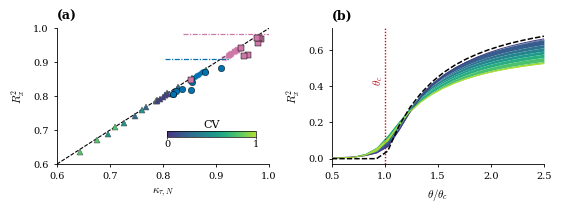

In [4]:
DS = {'tcga': dict(color=PALETTE['tcga'], marker=MARKERS['tcga'], label='TCGA'),
      'pbmc': dict(color=PALETTE['pbmc'], marker=MARKERS['pbmc'], label='PBMC')}
LIMS = (0.60, 1.00)
CV_RANGE = (0.0, 1.0)
HEIGHT_PT = 145.0

fig, (axa, axb) = figure(HEIGHT_PT, 2)

axa.plot(LIMS, LIMS, color=PALETTE['theory'], lw=0.8, ls=DASHES['theory_alt'],
         zorder=1)

lev = high_signal['rows']
cvs = np.array([r['cv'] for r in lev])
leverage_colors, sm = param_colors('cv', cvs, vmin=CV_RANGE[0], vmax=CV_RANGE[1])
for r, c in zip(lev, leverage_colors):
    axa.plot(r['kappa_tau'], np.mean(r['Rx2']), MARKERS['leverage'], ms=4.2,
             color=c, mec='0.3', mew=0.35, zorder=3)

for name, style in DS.items():
    e = ceil[name]
    bio = [r for r in e['rows'] if r['kind'] == 'bio']
    rnd = [r for r in e['rows'] if r['kind'] == 'random']
    axa.plot([r['kappa_tau'] for r in rnd], [np.mean(r['Rx2']) for r in rnd],
             style['marker'], ms=2.4, color=style['color'], alpha=0.40, lw=0,
             zorder=2)
    kt = np.array([r['kappa_tau'] for r in bio])
    mx = np.array([np.mean(r['Rx2']) for r in bio])
    axa.plot(kt, mx, style['marker'], ms=4.6, color=style['color'], mec='k',
             mew=0.35, lw=0, zorder=5)
    ku = e['kappa_uniform']
    lo, hi = kt.min() - 0.015, kt.max() + 0.015
    axa.hlines(ku, lo, hi, color=style['color'], lw=0.9,
               linestyles=[DASHES['ceiling']], zorder=4)

axa.set_xlim(*LIMS)
axa.set_xticks([0.6, 0.7, 0.8, 0.9, 1.0])
axa.set_xlabel(r'$\kappa_{\tau,N}$')
panel_label(axa, '(a)')

cax = axa.inset_axes([0.52, 0.20, 0.42, 0.045])
cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_ticks(list(CV_RANGE))
cb.set_ticklabels([f'{CV_RANGE[0]:g}', f'{CV_RANGE[1]:g}'])
cb.ax.tick_params(labelsize=PT['tick'], length=1.5, width=0.5, pad=1)
cb.outline.set_linewidth(0.5)
cax.set_title('CV', fontsize=PT['annot'], pad=2)

leverage_curves = results['finite_signal_leverage']
rows = leverage_curves['rows']
alpha_x, alpha_y = leverage_curves['alpha_x'], leverage_curves['alpha_y']
theta_c = leverage_curves['theta_c']
grid = np.array(sorted({r['theta'] for r in rows}))
xs = grid / theta_c

by_prof = {}
for r in rows:
    by_prof.setdefault(r['profile'], []).append(r)
spreads = sorted(by_prof, key=lambda k: np.mean([r['cv'] for r in by_prof[k]]))
cv_of = np.array([float(np.mean([r['cv'] for r in by_prof[k]])) for k in spreads])
curves = np.array([[float(np.mean([r['Rx2'] for r in by_prof[k]
                                   if r['theta'] == float(t)])) for t in grid]
                   for k in spreads])

band_cols, _ = param_colors('cv', (cv_of[:-1] + cv_of[1:]) / 2,
                               vmin=CV_RANGE[0], vmax=CV_RANGE[1])
for i in range(len(spreads) - 1):
    axb.fill_between(xs, curves[i + 1], curves[i], color=band_cols[i], lw=0,
                     zorder=2)
edge_cols, _ = param_colors('cv', cv_of[[0, -1]], vmin=CV_RANGE[0],
                            vmax=CV_RANGE[1])
for row, c in zip(curves[[0, -1]], edge_cols):
    axb.plot(xs, row, color=c, lw=0.7, zorder=3)

plug = np.array([theory.overlaps_at(alpha_x, alpha_y, leverage_curves['rho_x'], leverage_curves['rho_y'],
                                    float(t))[0] for t in grid])
axb.plot(xs, plug, color=PALETTE['theory'], lw=1.1, ls=DASHES['theory_alt'],
         zorder=4)
threshold_line(axb, 1.0, r'$\theta_c$', y=0.62)
axb.set_xlim(xs.min(), xs.max())
axb.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5])
axb.set_xlabel(r'$\theta/\theta_c$')
panel_label(axb, '(b)')

axa.set_ylim(*LIMS)
axa.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
axa.set_ylabel(r'$R_x^2$')
axb.set_ylim(-0.03, 0.72)
axb.set_ylabel(r'$R_x^2$')

save_figure(fig, 'fig8_direction_specific_ceilings')
for name in DS:
    e = ceil[name]
    bio = [r for r in e['rows'] if r['kind'] == 'bio']
    m = np.array([np.mean(r['Rx2']) for r in bio])
    kt = np.array([r['kappa_tau'] for r in bio])
    print(f'{name}: MAE vs kappa_tau {np.abs(m - kt).mean():.4f}, '
          f'vs equal-leverage kappa={e["kappa_uniform"]:.4f} '
          f'{np.abs(m - e["kappa_uniform"]).mean():.4f}')
print('high-signal CV %.2f..%.2f; panel (b) spans %.3f..%.3f over %d curves'
      % (cvs.min(), cvs.max(), cv_of.min(), cv_of.max(), len(spreads)))

trial_rows = high_signal['trial_rows']
trial_tau = np.array([r['tau'] for r in trial_rows])
trial_rx2 = np.array([r['Rx2'] for r in trial_rows])
trial_kappa = np.array([theory.kappa_tau(high_signal['rho_x'], tau)
                         for tau in trial_tau])
print(f'high-signal trial MAE: kappa_tau {np.mean(np.abs(trial_rx2 - trial_kappa)):.4f}; '
      f'equal-leverage kappa {np.mean(np.abs(trial_rx2 - high_signal["kappa_uniform"])):.4f}')
representative = results['finite_signal_profiles']
for profile, _, _ in p['high_signal_profiles']:
    selected = [r for r in representative['rows'] if r['profile'] == profile]
    theta = np.array(sorted({r['theta'] for r in selected}))
    measured = np.array([np.mean([r['Rx2'] for r in selected if r['theta'] == value])
                         for value in theta])
    predicted = np.array([theory.overlaps_at(
        representative['alpha_x'], representative['alpha_y'],
        representative['rho_x'], representative['rho_y'], value,
    )[0] for value in theta])
    supercritical = theta > 1.1 * representative['theta_c']
    print(f'{profile} finite-signal profile: CV {np.mean([r["cv"] for r in selected]):.3f}; '
          f'supercritical MAE {np.mean(np.abs(measured[supercritical] - predicted[supercritical])):.3f}')
for name, control in results['direction_controls'].items():
    gap = abs(control['Rx2_mean'] - control['kappa_tau_N'])
    budget = control['shortfall'] + 2 * control['Rx2_se']
    print(f'{name} matched direction control: gap {gap:.5f}; budget {budget:.5f}')
for name, block in sorted(results['detection'].items()):
    measured = detection_threshold(block['theta'], block['sigma1'], block['null_sigma1'])
    control = block['control']
    matched = detection_threshold(control['theta'], control['sigma1'], control['null_sigma1'])
    print(f'{name} half-crossing: {measured / block["theta_c"]:.3f}; '
          f'matched control {matched / control["theta_c"]:.3f}')
